In [291]:
%pip install seaborn
import seaborn as sns

In [292]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [293]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [294]:
df=pd.read_csv("customer_segmentation_dataset.csv")


In [295]:
print(df.head(10))

   Customer_ID   Age  Annual_Income  Purchase_Frequency  Annual_Spending  \
0            1  56.0       125186.0                 3.0        168969.96   
1            2  69.0        54674.0                40.0         12493.14   
2            3  46.0        55854.0                34.0        180843.59   
3            4  32.0        66271.0                40.0         94988.11   
4            5  60.0        93688.0                27.0        129254.29   
5            6  25.0        58518.0                13.0        133574.01   
6            7  38.0       131076.0                45.0        179547.96   
7            8  56.0        30267.0                33.0        129150.59   
8            9  36.0       110825.0                 NaN        124717.05   
9           10  40.0            NaN                24.0         17997.15   

   Spending_Score  Gender Region Income_Level  
0              44    Male  South         High  
1              33  Female   East       Medium  
2              81  

In [296]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         1000 non-null   int64  
 1   Age                 950 non-null    float64
 2   Annual_Income       950 non-null    float64
 3   Purchase_Frequency  950 non-null    float64
 4   Annual_Spending     950 non-null    float64
 5   Spending_Score      1000 non-null   int64  
 6   Gender              1000 non-null   object 
 7   Region              1000 non-null   object 
 8   Income_Level        950 non-null    object 
dtypes: float64(4), int64(2), object(3)
memory usage: 58.7+ KB


In [297]:
df.describe()

,Customer_ID,Age,Annual_Income,Purchase_Frequency,Annual_Spending,Spending_Score
count,1000.000000,950.000000,950.000000,950.000000,950.000000,1000.000000
mean,500.500000,43.804211,84836.464211,25.285263,106060.675337,51.257000
std,288.819436,14.914989,38195.517170,16.582129,85751.506252,28.300988
min,1.000000,18.000000,20077.000000,1.000000,5026.270000,1.000000
25%,250.750000,31.000000,52179.000000,13.000000,55464.012500,27.000000
50%,500.500000,44.000000,84699.000000,25.000000,102619.715000,53.000000
75%,750.250000,56.000000,117639.000000,37.000000,150843.617500,75.000000
max,1000.000000,69.000000,149972.000000,147.000000,998388.800000,100.000000


In [298]:
df.isnull().sum()

Customer_ID            0
Age                   50
Annual_Income         50
Purchase_Frequency    50
Annual_Spending       50
Spending_Score         0
Gender                 0
Region                 0
Income_Level          50
dtype: int64

In [299]:
num_cols = ['Annual_Spending', 'Purchase_Frequency', 'Age', 'Spending_Score','Customer_ID','Annual_Income']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
print(df[col])

0      125186.0
1       54674.0
2       55854.0
3       66271.0
4       93688.0
         ...   
995    145991.0
996     29516.0
997    132863.0
998    135005.0
999     22396.0
Name: Annual_Income, Length: 1000, dtype: float64


In [300]:
cat_cols = ['Income_Level', 'Region', 'Gender']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
print(df[col])   

0        Male
1      Female
2        Male
3        Male
4        Male
        ...  
995      Male
996      Male
997    Female
998    Female
999      Male
Name: Gender, Length: 1000, dtype: object


In [301]:
df.isnull().sum()

Customer_ID           0
Age                   0
Annual_Income         0
Purchase_Frequency    0
Annual_Spending       0
Spending_Score        0
Gender                0
Region                0
Income_Level          0
dtype: int64

In [302]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[((df[num_cols] < lower_bound) | (df[num_cols] > upper_bound)).any(axis=1)]

print(f"Number of outliers detected : {len(outliers)}")


Number of outliers detected : 5


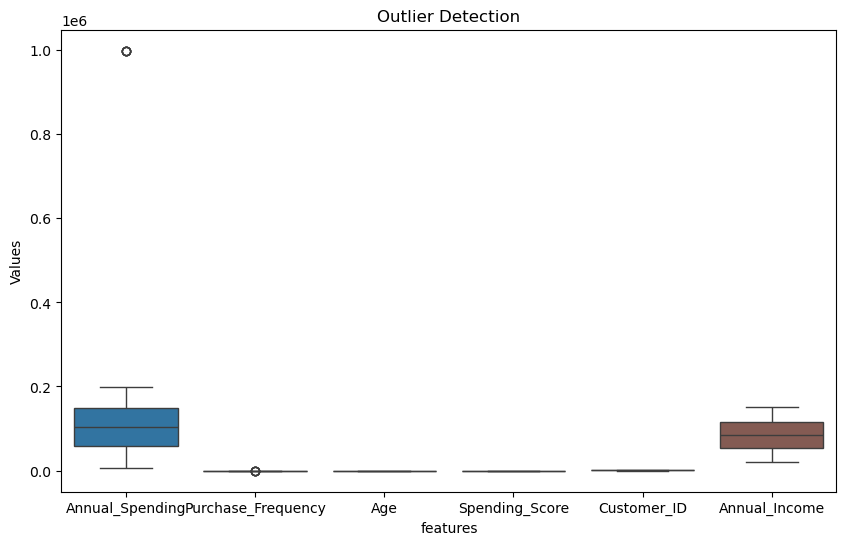

In [303]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[num_cols])
plt.title('Outlier Detection')
plt.ylabel('Values')
plt.xlabel('features')
plt.show()

In [304]:
m = ((df[num_cols] >= Q1 - 1.5*IQR) & (df[num_cols] <= Q3 + 1.5*IQR)).all(axis=1)

print(f"Dataset Shape before Deletion: {df.shape}")
df = df[m]
df.reset_index(drop=True, inplace=True)

print(f"Dataset Shape after Deletion: {df.shape}")

Dataset Shape before Deletion: (1000, 9)
Dataset Shape after Deletion: (995, 9)


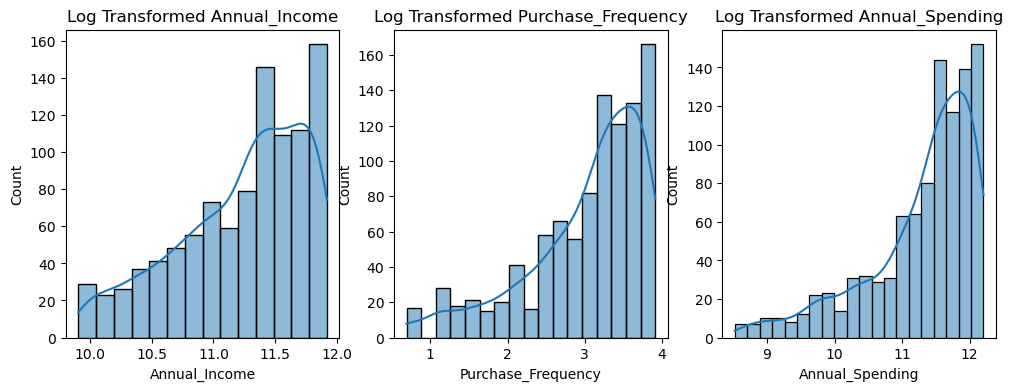

In [305]:
cols_to_transform = ['Annual_Income', 'Purchase_Frequency', 'Annual_Spending']
for col in cols_to_transform:
    df[col] = np.log1p(df[col])
plt.figure(figsize=(12, 4))
for i, col in enumerate(cols_to_transform):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Log Transformed {col}')
plt.show()

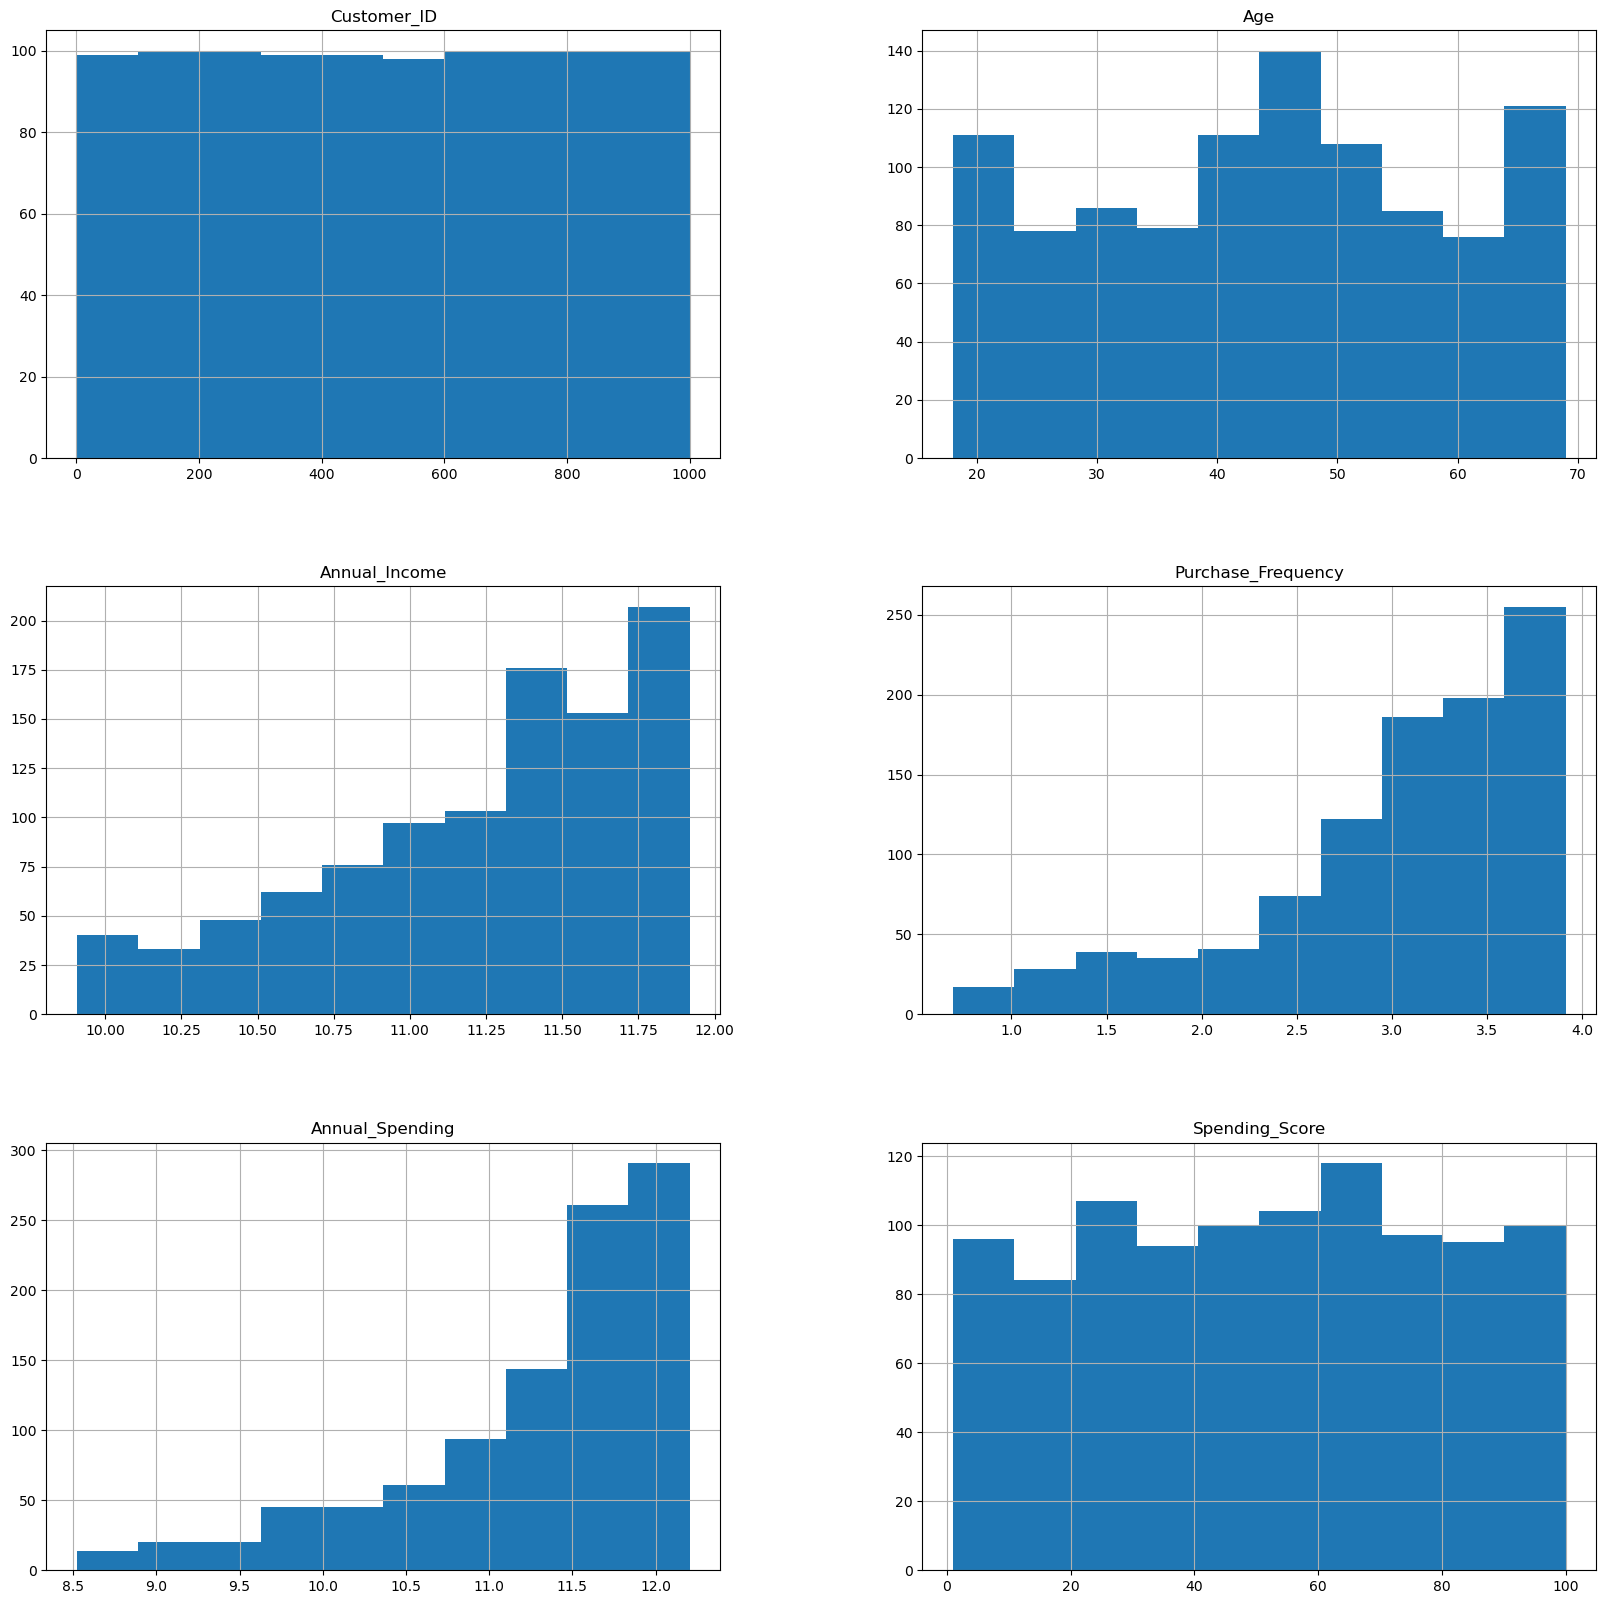

In [306]:
p=df.hist(figsize=(20,20))

In [307]:
print(df.columns)

Index(['Customer_ID', 'Age', 'Annual_Income', 'Purchase_Frequency',
       'Annual_Spending', 'Spending_Score', 'Gender', 'Region',
       'Income_Level'],
      dtype='object')


In [308]:
cols = ['Annual_Spending', 'Purchase_Frequency']
scaler = StandardScaler()

df[cols] = scaler.fit_transform(df[cols])
print(df.head(10))

   Customer_ID   Age  Annual_Income  Purchase_Frequency  Annual_Spending  \
0            1  56.0      11.737564           -2.141030         0.922714   
1            2  69.0      10.909162            0.898493        -2.294080   
2            3  46.0      10.930514            0.691846         1.006591   
3            4  32.0      11.101523            0.898493         0.211336   
4            5  60.0      11.447736            0.400411         0.591782   
5            6  25.0      10.977107           -0.504869         0.632385   
6            7  38.0      11.783540            1.048778         0.997711   
7            8  56.0      10.317846            0.653987         0.590791   
8            9  36.0      11.615717            0.303622         0.547647   
9           10  40.0      11.346871            0.252399        -1.843255   

   Spending_Score  Gender Region Income_Level  
0              44    Male  South         High  
1              33  Female   East       Medium  
2              81  

In [309]:
from sklearn.preprocessing import LabelEncoder

In [310]:

for coloumn in cat_cols:
    le = LabelEncoder()
    df[coloumn] = le.fit_transform(df[coloumn])
print(df.head(10))


   Customer_ID   Age  Annual_Income  Purchase_Frequency  Annual_Spending  \
0            1  56.0      11.737564           -2.141030         0.922714   
1            2  69.0      10.909162            0.898493        -2.294080   
2            3  46.0      10.930514            0.691846         1.006591   
3            4  32.0      11.101523            0.898493         0.211336   
4            5  60.0      11.447736            0.400411         0.591782   
5            6  25.0      10.977107           -0.504869         0.632385   
6            7  38.0      11.783540            1.048778         0.997711   
7            8  56.0      10.317846            0.653987         0.590791   
8            9  36.0      11.615717            0.303622         0.547647   
9           10  40.0      11.346871            0.252399        -1.843255   

   Spending_Score  Gender  Region  Income_Level  
0              44       1       2             0  
1              33       0       0             2  
2            

In [311]:
df = df.drop(columns=['Customer_ID'])


<Axes: >

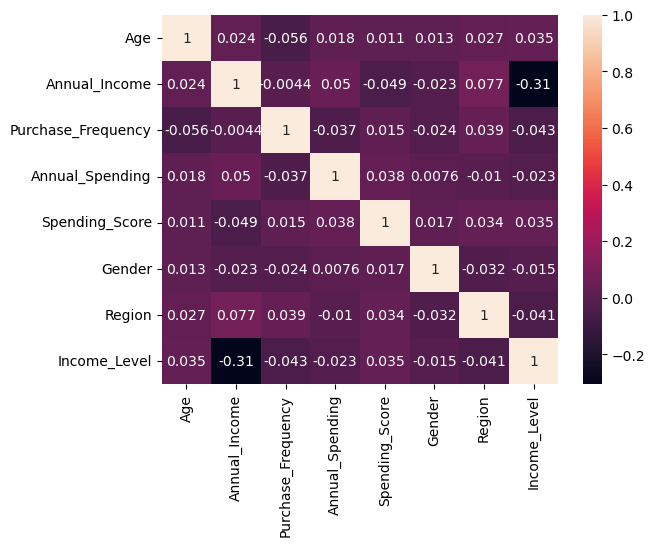

In [312]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)


In [313]:
df.var()


Age                   212.037323
Annual_Income           0.273665
Purchase_Frequency      1.001006
Annual_Spending         1.001006
Spending_Score        800.939531
Gender                  0.250140
Region                  1.186732
Income_Level            0.734402
dtype: float64

In [314]:
df = df.drop(columns=['Gender', 'Region', 'Income_Level'])


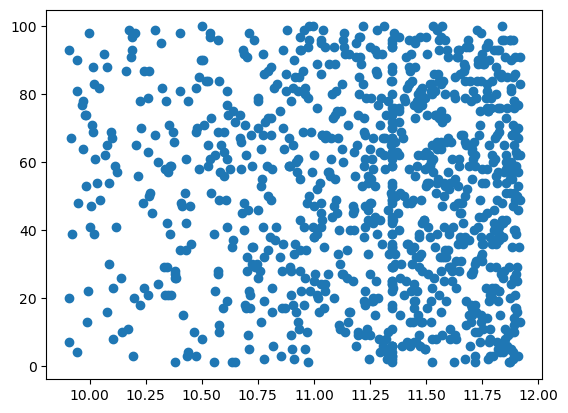

In [315]:
plt.scatter(df['Annual_Income'], df['Spending_Score'])
plt.show()


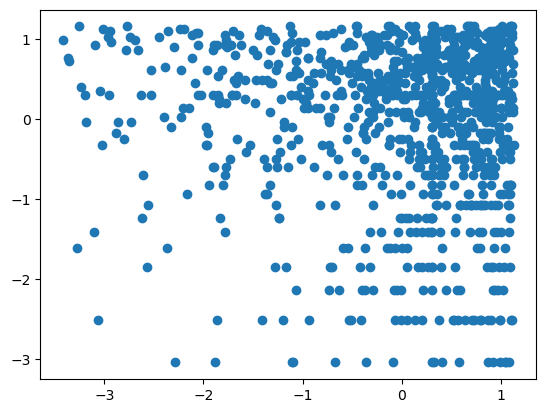

In [316]:
plt.scatter(df['Annual_Spending'], df['Purchase_Frequency'])
plt.show()


In [317]:
features = ['Annual_Spending', 'Purchase_Frequency']
data_for_clustering = df[features] 
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_for_clustering )
    wcss.append(kmeans.inertia_)

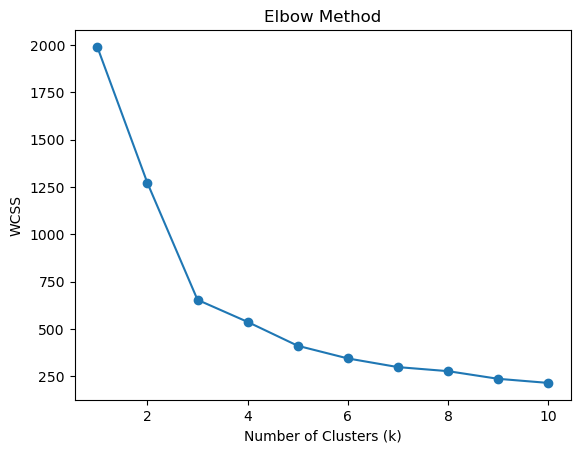

In [318]:
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

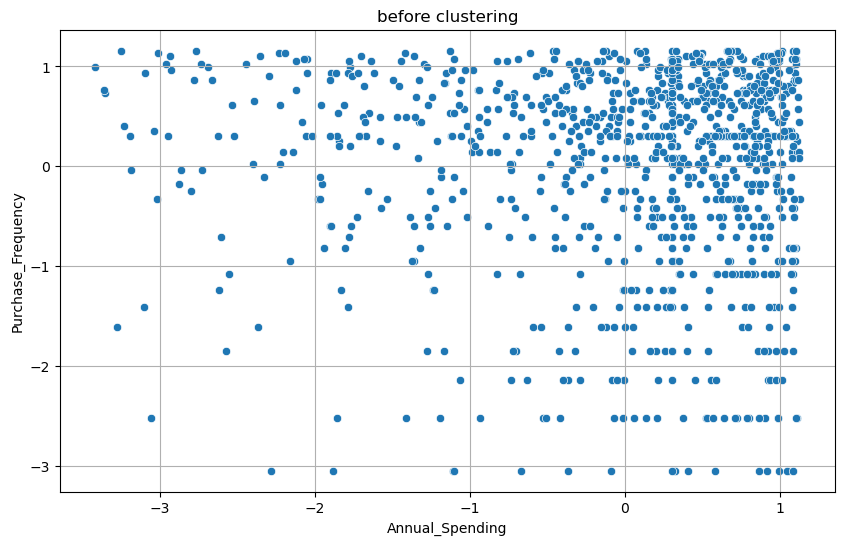

In [319]:
# before clustering
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual_Spending', y='Purchase_Frequency')
plt.title('before clustering')
plt.grid(True)
plt.show()

In [320]:
final_kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster_ID'] = final_kmeans.fit_predict(data_for_clustering)
print(df.head())

    Age  Annual_Income  Purchase_Frequency  Annual_Spending  Spending_Score  \
0  56.0      11.737564           -2.141030         0.922714              44   
1  69.0      10.909162            0.898493        -2.294080              33   
2  46.0      10.930514            0.691846         1.006591              81   
3  32.0      11.101523            0.898493         0.211336              75   
4  60.0      11.447736            0.400411         0.591782              77   

   Cluster_ID  
0           2  
1           1  
2           0  
3           0  
4           0  


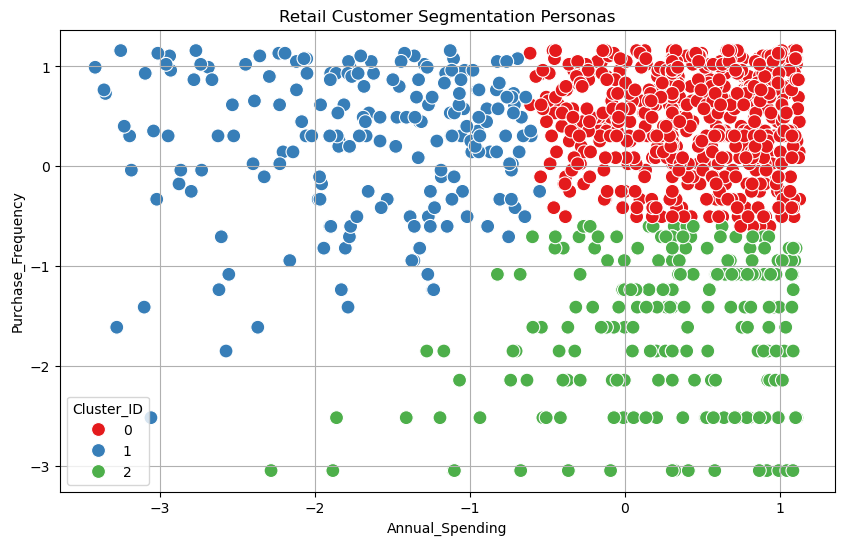

In [321]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual_Spending', y='Purchase_Frequency', hue='Cluster_ID', palette='Set1', s=100)
plt.title('Retail Customer Segmentation Personas')
plt.grid(True)
plt.show()

In [322]:
from sklearn.metrics import silhouette_score
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(data_for_clustering)
score = silhouette_score(data_for_clustering, labels, metric='euclidean')
print(f"Silhouette Score: {score}")


Silhouette Score: 0.4933228178044535


In [323]:
wcss


[1990.0000000000007,
 1270.7261407469339,
 653.0951124650428,
 536.4204114413398,
 410.2603382194057,
 343.3570988565331,
 297.5604136547559,
 276.10946161744226,
 235.6836985268305,
 213.93084111144697]